# Multivariate Linear Regression — AQ-10 Autism Screening Result

**Mission:** predict a person's AQ-10 autism-screening `result` using only
accessible, non-behavioral information (age, family history of autism, country
of residence, jaundice at birth, etc.) — without needing the full 10-question
behavioral interview (A1–A10). This supports lightweight pre-screening in
regions or families that don't have easy access to the full assessment.

Built from three merged datasets (Fadi Thabtah, UCI ML Repository): Adult,
Child, and Adolescent autism screening data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib

SEQ_BLUE = "#2a78d6"

## Step 1 — Load and merge

In [2]:
adult = pd.read_csv('Autism_Adult_Data.csv')
adult['age_group'] = 'adult'

child = pd.read_csv('Autism_Child_Data.csv')
child['age_group'] = 'child'

adolescent = pd.read_csv('Autism_Adolescent_Data.csv')
adolescent['age_group'] = 'adolescent'

df = pd.concat([adult, child, adolescent], ignore_index=True)

print(df.shape)
df.info()

(1100, 23)
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               1100 non-null   int64 
 1   A1_Score         1100 non-null   int64 
 2   A2_Score         1100 non-null   int64 
 3   A3_Score         1100 non-null   int64 
 4   A4_Score         1100 non-null   int64 
 5   A5_Score         1100 non-null   int64 
 6   A6_Score         1100 non-null   int64 
 7   A7_Score         1100 non-null   int64 
 8   A8_Score         1100 non-null   int64 
 9   A9_Score         1100 non-null   int64 
 10  A10_Score        1100 non-null   int64 
 11  age              1100 non-null   object
 12  gender           1100 non-null   str   
 13  ethnicity        1100 non-null   str   
 14  jundice          1100 non-null   str   
 15  austim           1100 non-null   str   
 16  contry_of_res    1100 non-null   str   
 17  used_app_before  1100 non-null   

## Step 2 — Clean

In [3]:
df = df.drop(columns=['id', 'Class/ASD'])

df['ethnicity'] = df['ethnicity'].replace('?', 'Unknown')
df['relation'] = df['relation'].replace('?', 'Unknown')

# age arrives as a mix of str/int across the 3 source files and has a
# handful of '?' placeholders (adult + child); coerce to numeric and
# drop the few rows that can't be parsed.
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print('rows dropped for unparseable age:', df['age'].isna().sum())
df = df.dropna(subset=['age'])

# one adult-data row records age=383 (data-entry error, not a real human
# age) which skews the age-vs-result relationship explored in Step 7.
print('rows dropped for implausible age (>120):', (df['age'] > 120).sum())
df = df[df['age'] <= 120].reset_index(drop=True)

df.shape

rows dropped for unparseable age: 6
rows dropped for implausible age (>120): 1


(1093, 21)

In [4]:
a_score_cols = [f'A{i}_Score' for i in range(1, 11)]
df = df.drop(columns=a_score_cols)
df.shape

(1093, 11)

### Why A1–A10 are dropped

`result` (the AQ-10 score) is the arithmetic sum of the ten `A1_Score`–
`A10_Score` answers. Keeping those columns as features would let the model
just re-add them — a deterministic, trivial mapping with near-zero error that
says nothing about screening someone *without* the behavioral checklist.
Since the mission is to predict `result` from accessible, non-behavioral
information, the ten item scores are dropped entirely, along with
`Class/ASD` (a direct threshold of `result`, i.e. leakage) and `id` (a row
identifier with no predictive value).

## Step 3 — Exploratory Data Analysis

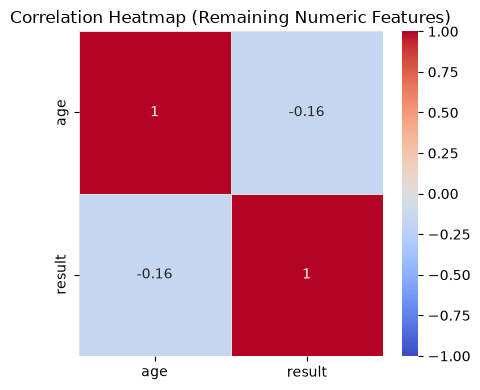

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(4.5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#e1e0d9')
plt.title('Correlation Heatmap (Remaining Numeric Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

**Interpretation:** at this stage in the pipeline the only numeric columns
left are `age` and `result` (everything else is still categorical text,
label-encoded in Step 4). Their correlation is weak and negative
(r ≈ -0.16): older respondents in this merged dataset score marginally
*lower* on the AQ-10, but age alone explains very little of the variance in
`result` — expected, since age is a coarse demographic proxy, not a
behavioral signal.

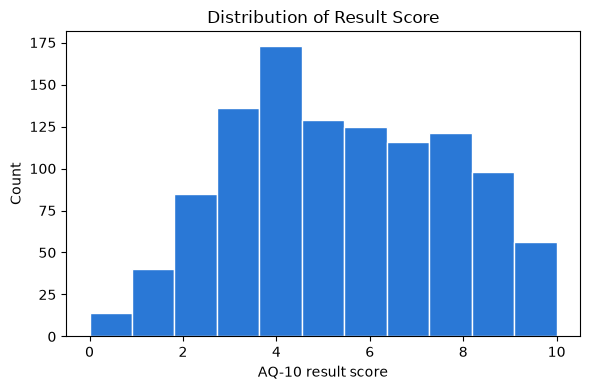

In [6]:
plt.figure(figsize=(6, 4))
df['result'].plot(kind='hist', bins=11, color=SEQ_BLUE, edgecolor='white')
plt.xlabel('AQ-10 result score')
plt.ylabel('Count')
plt.title('Distribution of Result Score')
plt.tight_layout()
plt.savefig('result_histogram.png', dpi=150)
plt.show()

**Interpretation:** `result` spans the full 0–10 range with mean ≈ 5.4 and
std ≈ 2.5, and is close to symmetric (skew ≈ 0.05) rather than the
"mostly-low-scores" shape you'd expect from a general, unscreened population.
That reflects what this dataset actually is — a curated screening sample
rather than a random draw of the population — and is worth keeping in mind
when judging how the model's error generalizes to other populations.

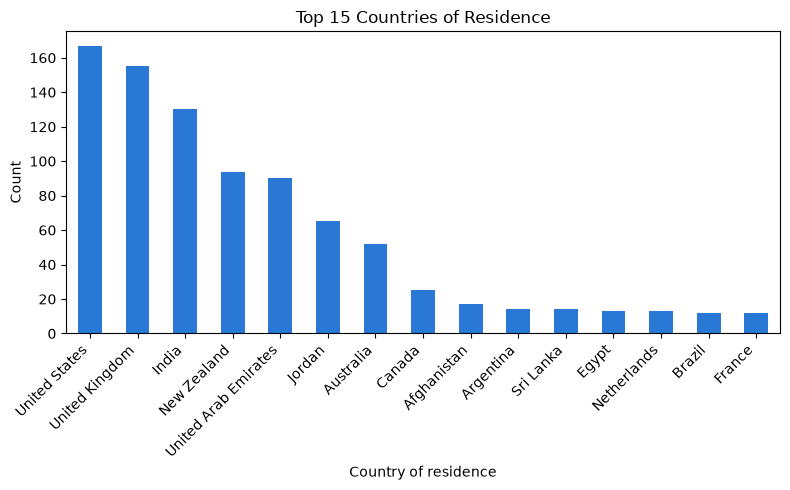

In [7]:
top_countries = df['contry_of_res'].value_counts().head(15)
plt.figure(figsize=(8, 5))
top_countries.plot(kind='bar', color=SEQ_BLUE)
plt.ylabel('Count')
plt.xlabel('Country of residence')
plt.title('Top 15 Countries of Residence')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('country_distribution.png', dpi=150)
plt.show()

**Interpretation:** respondents span 89 countries but are heavily
concentrated in a handful — United States (167), United Kingdom (155), and
India (130) alone account for roughly 40% of all rows, with New Zealand,
UAE, and Jordan rounding out the top tier. `contry_of_res` is a long-tail
categorical feature: label encoding keeps it usable, but the model will see
far more examples from these top countries than from most of the other ~80.

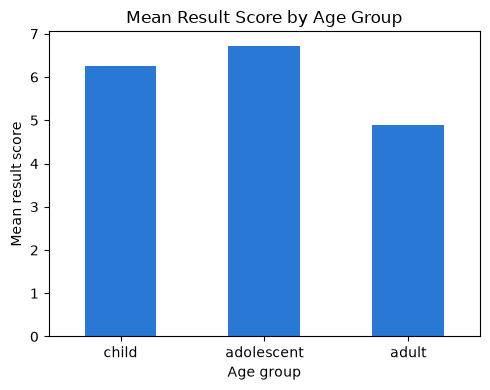

In [8]:
group_order = ['child', 'adolescent', 'adult']
mean_by_group = df.groupby('age_group')['result'].mean().reindex(group_order)
plt.figure(figsize=(5, 4))
mean_by_group.plot(kind='bar', color=SEQ_BLUE)
plt.ylabel('Mean result score')
plt.xlabel('Age group')
plt.title('Mean Result Score by Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('result_by_age_group.png', dpi=150)
plt.show()

**Interpretation:** mean `result` differs noticeably by age group —
adolescent ≈ 6.72, child ≈ 6.25, adult ≈ 4.89. Adults screen lower on
average than children/adolescents in this merged sample, which is exactly
the kind of demographic structure the model should be able to pick up on
even without any behavioral answers, and is part of why `age_group` is kept
as a feature.

## Step 4 — Feature engineering

In [9]:
encode_cols = ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
               'used_app_before', 'relation', 'age_group', 'age_desc']

encoders = {}
for col in encode_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = ['age', 'gender', 'ethnicity', 'jundice', 'austim',
                'contry_of_res', 'used_app_before', 'relation', 'age_group']
target_col = 'result'

X = df[feature_cols]
y = df[target_col]
X.head()

,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,relation,age_group
0,26.0,0,10,0,0,86,0,4,1
1,24.0,1,3,0,1,17,0,4,1
2,27.0,1,3,1,1,76,0,2,1
3,35.0,0,10,0,1,86,0,4,1
4,40.0,0,9,0,0,29,0,5,1


## Step 5 — Split and scale

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((874, 9), (219, 9))

## Step 6 — Train and compare 4 models

In [11]:
sgd = SGDRegressor(random_state=42)
n_epochs = 200
sgd_train_mse = []
sgd_test_mse = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    sgd_train_mse.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    sgd_test_mse.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

print(f'SGDRegressor MSE: {sgd_test_mse[-1]:.4f}')

SGDRegressor MSE: 6.3162


In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_reg_mse = mean_squared_error(y_test, lin_reg.predict(X_test_scaled))
print(f'LinearRegression MSE: {lin_reg_mse:.4f}')

LinearRegression MSE: 6.3069


In [13]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_scaled, y_train)
tree_reg_mse = mean_squared_error(y_test, tree_reg.predict(X_test_scaled))
print(f'DecisionTreeRegressor MSE: {tree_reg_mse:.4f}')

DecisionTreeRegressor MSE: 9.4572


In [14]:
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_scaled, y_train)
forest_reg_mse = mean_squared_error(y_test, forest_reg.predict(X_test_scaled))
print(f'RandomForestRegressor MSE: {forest_reg_mse:.4f}')

RandomForestRegressor MSE: 5.9047


## Step 7 — Plots

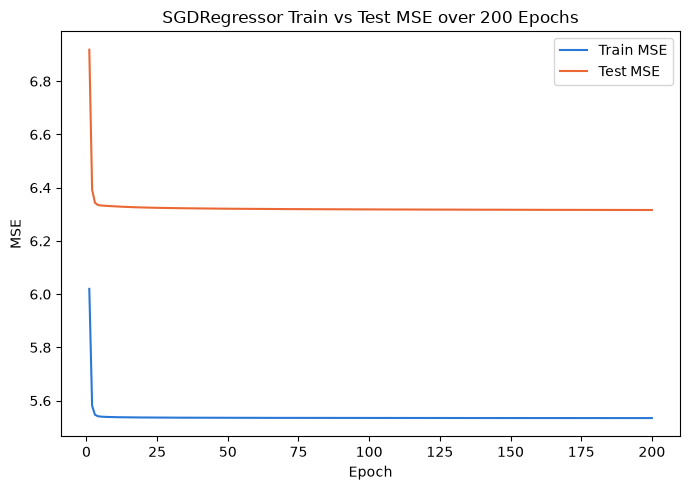

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, n_epochs + 1), sgd_train_mse, label='Train MSE', color=SEQ_BLUE)
plt.plot(range(1, n_epochs + 1), sgd_test_mse, label='Test MSE', color='#eb6834')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('SGDRegressor Train vs Test MSE over 200 Epochs')
plt.legend()
plt.tight_layout()
plt.savefig('sgd_loss_curve.png', dpi=150)
plt.show()

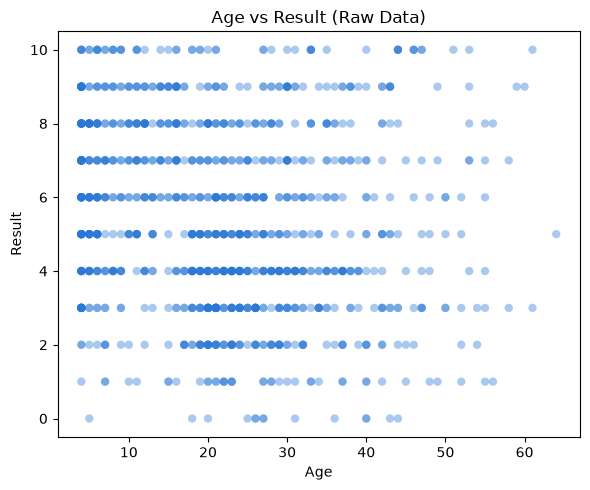

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(df['age'], df['result'], alpha=0.4, color=SEQ_BLUE, edgecolor='none')
plt.xlabel('Age')
plt.ylabel('Result')
plt.title('Age vs Result (Raw Data)')
plt.tight_layout()
plt.savefig('age_vs_result_before.png', dpi=150)
plt.show()

C:\Users\divin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


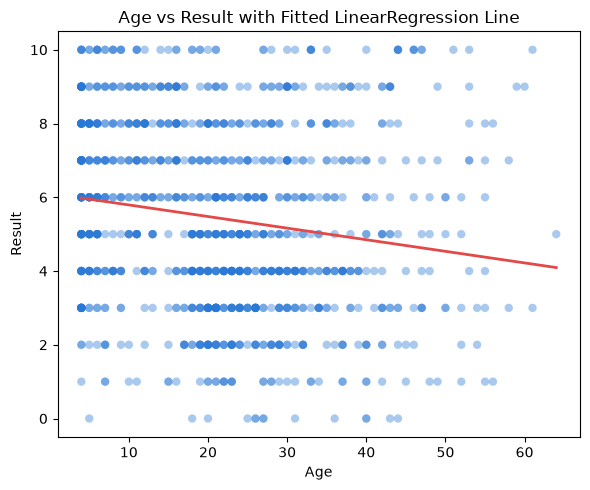

In [17]:
age_only = df[['age']]
age_reg = LinearRegression()
age_reg.fit(age_only, y)
age_line_x = np.linspace(df['age'].min(), df['age'].max(), 100).reshape(-1, 1)
age_line_y = age_reg.predict(age_line_x)

plt.figure(figsize=(6, 5))
plt.scatter(df['age'], df['result'], alpha=0.4, color=SEQ_BLUE, edgecolor='none')
plt.plot(age_line_x, age_line_y, color='#e34948', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Result')
plt.title('Age vs Result with Fitted LinearRegression Line')
plt.tight_layout()
plt.savefig('age_vs_result_after.png', dpi=150)
plt.show()